In [1]:
import pandas as pd
import os

In [2]:
path = r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw"
files = os.listdir(path)
print(files)

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv']


In [3]:
df = pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\01_fund_master.csv")
print("Shape:")
print(df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Shape:
(40, 15)

First 5 Rows:
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_si

In [4]:
print("Unique Fund Houses:")
print(df["fund_house"].unique())
print("\nNumber of Fund Houses:")
print(df["fund_house"].nunique())
print("\nCategories:")
print(df["category"].unique())
print("\nSub Categories:")
print(df["sub_category"].unique())
print("\nRisk Categories:")
print(df["risk_category"].unique())

Unique Fund Houses:
['SBI Mutual Fund' 'HDFC Mutual Fund' 'ICICI Prudential MF'
 'Nippon India MF' 'Kotak Mahindra MF' 'Axis Mutual Fund'
 'Aditya Birla Sun Life MF' 'UTI Mutual Fund' 'Mirae Asset MF'
 'DSP Mutual Fund']

Number of Fund Houses:
10

Categories:
['Equity' 'Debt']

Sub Categories:
['Large Cap' 'Small Cap' 'Gilt' 'Mid Cap' 'Short Duration' 'Value'
 'Liquid' 'Index/ETF' 'Flexi Cap' 'Index' 'Large & Mid Cap' 'ELSS']

Risk Categories:
['Moderate' 'Very High' 'Low' 'High' 'Moderately High']


In [5]:
print("\nAMFI Codes Sample:")
print(df["amfi_code"].head())
print("\nTotal Unique AMFI Codes:")
print(df["amfi_code"].nunique())


AMFI Codes Sample:
0    119551
1    119552
2    119598
3    119599
4    119120
Name: amfi_code, dtype: int64

Total Unique AMFI Codes:
40


In [6]:
nav_df = pd.read_csv(
    r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\02_nav_history.csv"
)
print(nav_df.shape)
print(nav_df.head())
print(nav_df.columns.tolist())

(46000, 3)
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
['amfi_code', 'date', 'nav']


In [8]:
master_codes = set(df["amfi_code"])
nav_codes = set(nav_df["amfi_code"])
missing_codes = master_codes - nav_codes
print("Total Fund Master Codes:", len(master_codes))
print("Total NAV Codes:", len(nav_codes))
print("Missing Codes:", len(missing_codes))
print("\nMissing Code List:")
print(missing_codes)

Total Fund Master Codes: 40
Total NAV Codes: 40
Missing Codes: 0

Missing Code List:
set()


In [9]:
path = r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw"
files = os.listdir(path)
for file in files:
    if file.endswith(".csv"):
        print("\n" + "="*60)
        print(file)

        df_temp = pd.read_csv(os.path.join(path, file))

        print("Shape:", df_temp.shape)
        print("Missing Values:", df_temp.isnull().sum().sum())
        print("Duplicates:", df_temp.duplicated().sum())


01_fund_master.csv
Shape: (40, 15)
Missing Values: 0
Duplicates: 0

02_nav_history.csv
Shape: (46000, 3)
Missing Values: 0
Duplicates: 0

03_aum_by_fund_house.csv
Shape: (90, 5)
Missing Values: 0
Duplicates: 0

04_monthly_sip_inflows.csv
Shape: (48, 6)
Missing Values: 12
Duplicates: 0

05_category_inflows.csv
Shape: (144, 3)
Missing Values: 0
Duplicates: 0

06_industry_folio_count.csv
Shape: (21, 6)
Missing Values: 0
Duplicates: 0

07_scheme_performance.csv
Shape: (40, 19)
Missing Values: 0
Duplicates: 0

08_investor_transactions.csv
Shape: (32778, 13)
Missing Values: 0
Duplicates: 0

09_portfolio_holdings.csv
Shape: (322, 8)
Missing Values: 0
Duplicates: 0

10_benchmark_indices.csv
Shape: (8050, 3)
Missing Values: 0
Duplicates: 0


In [10]:
import requests
import pandas as pd

url = "https://api.mfapi.in/mf/125497"

response = requests.get(url)

data = response.json()

print(data["meta"]["scheme_name"])

nav_df_live = pd.DataFrame(data["data"])

nav_df_live.head()

SBI Small Cap Fund - Direct Plan - Growth


,date,nav
0,01-06-2026,192.31950
1,31-05-2026,193.68360
2,29-05-2026,193.68480
3,27-05-2026,195.05010
4,26-05-2026,194.22580


In [11]:
nav_df_live.to_csv(
    r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\HDFC_Top100_Live_NAV.csv",
    index=False
)
print("CSV Saved Successfully")

CSV Saved Successfully


In [12]:
schemes = {
    "HDFC_Top100": 125497,
    "SBI_Bluechip": 119551,
    "ICICI_Bluechip": 120503,
    "Nippon_Large_Cap": 118632,
    "Axis_Bluechip": 119092,
    "Kotak_Bluechip": 120841
}
save_path = r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw"
for scheme_name, code in schemes.items():

    url = f"https://api.mfapi.in/mf/{code}"

    response = requests.get(url)

    data = response.json()

    nav_df = pd.DataFrame(data["data"])

    nav_df.to_csv(
        f"{save_path}\\{scheme_name}_Live_NAV.csv",
        index=False
    )

    print(f"{scheme_name} saved successfully")

HDFC_Top100 saved successfully
SBI_Bluechip saved successfully
ICICI_Bluechip saved successfully
Nippon_Large_Cap saved successfully


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [13]:
schemes = {
    "HDFC_Top100": 125497,
    "SBI_Bluechip": 119551,
    "ICICI_Bluechip": 120503,
    "Nippon_Large_Cap": 118632,
    "Axis_Bluechip": 119092,
    "Kotak_Bluechip": 120841
}

for name, code in schemes.items():

    url = f"https://api.mfapi.in/mf/{code}"

    response = requests.get(url)

    print(f"\n{name}")
    print("Status Code:", response.status_code)
    print("First 100 characters:")
    print(response.text[:100])


HDFC_Top100
Status Code: 502
First 100 characters:
<html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></cente

SBI_Bluechip
Status Code: 502
First 100 characters:
<html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></cente

ICICI_Bluechip
Status Code: 502
First 100 characters:
<html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></cente

Nippon_Large_Cap
Status Code: 200
First 100 characters:
{"meta":{"fund_house":"Nippon India Mutual Fund","scheme_type":"Open Ended Schemes","scheme_category

Axis_Bluechip
Status Code: 200
First 100 characters:
{"meta":{"fund_house":"HDFC Mutual Fund","scheme_type":"Open Ended Schemes","scheme_category":"Debt 

Kotak_Bluechip
Status Code: 200
First 100 characters:
{"meta":{"fund_house":"quant Mutual Fund","scheme_type":"Open Ended Schemes","scheme_category":"Equi


In [14]:
schemes = {
    "Nippon_Large_Cap": 118632,
    "Axis_Bluechip": 119092,
    "Kotak_Bluechip": 120841
}

save_path = r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw"

for name, code in schemes.items():

    try:
        url = f"https://api.mfapi.in/mf/{code}"

        response = requests.get(url)

        if response.status_code == 200:

            data = response.json()

            nav_df = pd.DataFrame(data["data"])

            nav_df.to_csv(
                os.path.join(save_path, f"{name}_Live_NAV.csv"),
                index=False
            )

            print(f"Saved: {name}")

        else:
            print(f"Failed: {name} - Status {response.status_code}")

    except Exception as e:
        print(f"Error for {name}: {e}")

Failed: Nippon_Large_Cap - Status 502
Failed: Axis_Bluechip - Status 502
Failed: Kotak_Bluechip - Status 502


In [38]:
fund_master = pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\01_fund_master.csv")
nav_history = pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\02_nav_history.csv")
scheme_performance = pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\07_scheme_performance.csv")
transactions = pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\08_investor_transactions.csv")

In [39]:
import pandas as pd
import numpy as np
fund_master = pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\01_fund_master.csv")
nav_history = pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\02_nav_history.csv")
scheme_performance = pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\07_scheme_performance.csv")
transactions = pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw\08_investor_transactions.csv")

In [40]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)
nav_history["nav"] = nav_history.groupby(
    "amfi_code"
)["nav"].ffill()
nav_history = nav_history.drop_duplicates()
nav_history = nav_history[
    nav_history["nav"] > 0
]
print(nav_history.shape)

(46000, 3)


In [41]:
nav_history.to_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_nav_history.csv",
index=False
)

In [42]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [43]:
print(transactions["transaction_type"].value_counts())

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


In [44]:
print(transactions["kyc_status"].value_counts())

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64


In [45]:
print(transactions["amount_inr"].describe())

count     32778.000000
mean     107437.318628
std      150415.905084
min         400.000000
25%        3153.000000
50%       17782.500000
75%      189324.250000
max      597498.000000
Name: amount_inr, dtype: float64


In [46]:
print((transactions["amount_inr"] <= 0).sum())

0


In [47]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print(transactions.dtypes)

investor_id                   object
transaction_date      datetime64[ns]
amfi_code                      int64
transaction_type              object
amount_inr                     int64
state                         object
city                          object
city_tier                     object
age_group                     object
gender                        object
annual_income_lakh           float64
payment_mode                  object
kyc_status                    object
dtype: object


In [48]:
transactions.to_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_investor_transactions.csv",
index=False
)
print("Transactions cleaned and saved")

Transactions cleaned and saved


In [49]:
print(scheme_performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [50]:
print(scheme_performance.isnull().sum())

amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64


In [51]:
return_cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "benchmark_3yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "sortino_ratio",
    "std_dev_ann_pct",
    "max_drawdown_pct",
    "aum_crore",
    "expense_ratio_pct"
]

print(scheme_performance[return_cols].dtypes)

return_1yr_pct       float64
return_3yr_pct       float64
return_5yr_pct       float64
benchmark_3yr_pct    float64
alpha                float64
beta                 float64
sharpe_ratio         float64
sortino_ratio        float64
std_dev_ann_pct      float64
max_drawdown_pct     float64
aum_crore              int64
expense_ratio_pct    float64
dtype: object


In [52]:
anomalies = scheme_performance[
    (scheme_performance["expense_ratio_pct"] < 0.1) |
    (scheme_performance["expense_ratio_pct"] > 2.5)
]

print("Expense Ratio Anomalies:")
print(anomalies[["scheme_name", "expense_ratio_pct"]])

Expense Ratio Anomalies:
Empty DataFrame
Columns: [scheme_name, expense_ratio_pct]
Index: []


In [53]:
for col in return_cols:
    scheme_performance[col] = pd.to_numeric(
        scheme_performance[col],
        errors="coerce"
    )

print(scheme_performance[return_cols].isnull().sum())

return_1yr_pct       0
return_3yr_pct       0
return_5yr_pct       0
benchmark_3yr_pct    0
alpha                0
beta                 0
sharpe_ratio         0
sortino_ratio        0
std_dev_ann_pct      0
max_drawdown_pct     0
aum_crore            0
expense_ratio_pct    0
dtype: int64


In [54]:
scheme_performance.to_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_scheme_performance.csv",
index=False
)

print("Scheme Performance cleaned and saved")

Scheme Performance cleaned and saved


In [55]:
print(scheme_performance.isnull().sum())

amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64


In [56]:
anomalies = scheme_performance[
    (scheme_performance["expense_ratio_pct"] < 0.1) |
    (scheme_performance["expense_ratio_pct"] > 2.5)
]

print("Expense Ratio Anomalies:")
print(anomalies[["scheme_name", "expense_ratio_pct"]])

Expense Ratio Anomalies:
Empty DataFrame
Columns: [scheme_name, expense_ratio_pct]
Index: []


In [57]:
base_raw = r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Raw"
base_processed = r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed"

In [58]:
fund_master = pd.read_csv(f"{base_raw}\\01_fund_master.csv")
aum = pd.read_csv(f"{base_raw}\\03_aum_by_fund_house.csv")
sip = pd.read_csv(f"{base_raw}\\04_monthly_sip_inflows.csv")
category = pd.read_csv(f"{base_raw}\\05_category_inflows.csv")
folio = pd.read_csv(f"{base_raw}\\06_industry_folio_count.csv")
holdings = pd.read_csv(f"{base_raw}\\09_portfolio_holdings.csv")
benchmark = pd.read_csv(f"{base_raw}\\10_benchmark_indices.csv")

In [59]:
print(sip.isnull().sum())

month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64


In [60]:
sip["month"] = pd.to_datetime(sip["month"])
sip = sip.drop_duplicates()
print(sip.shape)

(48, 6)


In [61]:
sip.to_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_monthly_sip_inflows.csv",
index=False
)

In [62]:
fund_master.to_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_fund_master.csv",
index=False
)
aum.to_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_aum_by_fund_house.csv",
index=False
)
category.to_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_category_inflows.csv",
index=False
)
folio.to_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_industry_folio_count.csv",
index=False
)
holdings.to_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_portfolio_holdings.csv",
index=False
)
benchmark.to_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_benchmark_indices.csv",
index=False
)
print("All cleaned datasets saved")

All cleaned datasets saved


In [63]:
import sqlalchemy
print(sqlalchemy.__version__)

2.0.48


In [64]:
from sqlalchemy import create_engine
engine = create_engine(
    r"sqlite:///C:/Users/karan/OneDrive/Desktop/Mutual_Fund_Capstone_Project/bluestock_mf.db"
)
print("Database Created Successfully")

Database Created Successfully


In [65]:
clean_fund_master = pd.read_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_fund_master.csv"
)
clean_nav_history = pd.read_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_nav_history.csv"
)
clean_transactions = pd.read_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_investor_transactions.csv"
)
clean_performance = pd.read_csv(
r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed\clean_scheme_performance.csv"
)

In [66]:
clean_fund_master.to_sql(
    "dim_fund",
    engine,
    if_exists="replace",
    index=False
)

clean_nav_history.to_sql(
    "fact_nav",
    engine,
    if_exists="replace",
    index=False
)

clean_transactions.to_sql(
    "fact_transactions",
    engine,
    if_exists="replace",
    index=False
)

clean_performance.to_sql(
    "fact_performance",
    engine,
    if_exists="replace",
    index=False
)

print("Tables Loaded Successfully")

Tables Loaded Successfully


In [67]:
from sqlalchemy import text
with engine.connect() as conn:
    tables = [
        "dim_fund",
        "fact_nav",
        "fact_transactions",
        "fact_performance"
    ]

    for table in tables:

        result = conn.execute(
            text(f"SELECT COUNT(*) FROM {table}")
        )

        print(table, result.scalar())

dim_fund 40
fact_nav 46000
fact_transactions 32778
fact_performance 40


In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

<Figure size 1200x600 with 0 Axes>

In [69]:
base = r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Data\Processed"

fund_master = pd.read_csv(f"{base}\\clean_fund_master.csv")
nav = pd.read_csv(f"{base}\\clean_nav_history.csv")
aum = pd.read_csv(f"{base}\\clean_aum_by_fund_house.csv")
sip = pd.read_csv(f"{base}\\clean_monthly_sip_inflows.csv")
category = pd.read_csv(f"{base}\\clean_category_inflows.csv")
folio = pd.read_csv(f"{base}\\clean_industry_folio_count.csv")
performance = pd.read_csv(f"{base}\\clean_scheme_performance.csv")
transactions = pd.read_csv(f"{base}\\clean_investor_transactions.csv")
holdings = pd.read_csv(f"{base}\\clean_portfolio_holdings.csv")
benchmark = pd.read_csv(f"{base}\\clean_benchmark_indices.csv")

In [70]:
nav["date"] = pd.to_datetime(nav["date"])

In [71]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

In [72]:
fig.write_html("nav_trend.html")

In [73]:
print(aum.columns.tolist())
print(sip.columns.tolist())
print(category.columns.tolist())
print(folio.columns.tolist())
print(holdings.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
['month', 'category', 'net_inflow_crore']
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [74]:
import seaborn as sns
import plotly.express as px

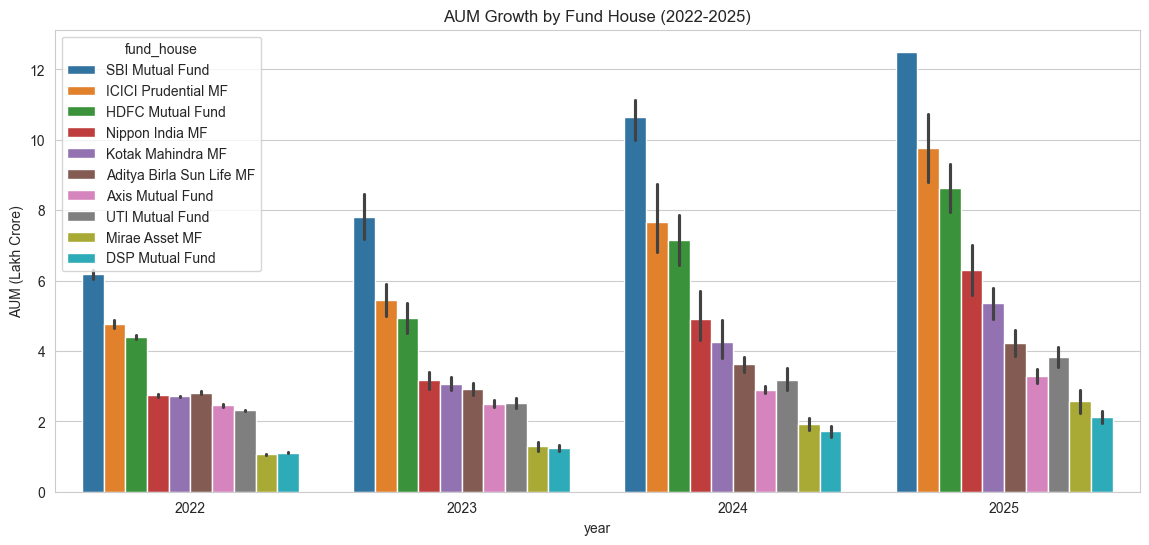

In [75]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.ylabel("AUM (Lakh Crore)")
plt.show()

In [76]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)

fig.add_annotation(
    x=sip.loc[sip["sip_inflow_crore"].idxmax(),"month"],
    y=sip["sip_inflow_crore"].max(),
    text="All Time High",
    showarrow=True
)

fig.show()

In [77]:
import plotly.io as pio

pio.renderers.default = "browser"

In [78]:
fig.show()

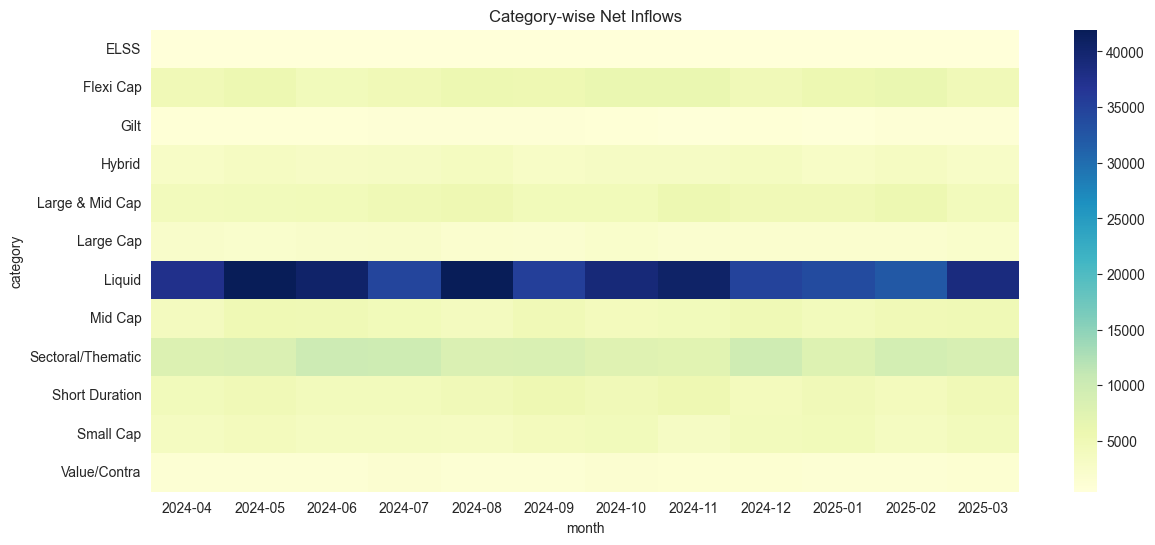

In [79]:
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows")
plt.show()

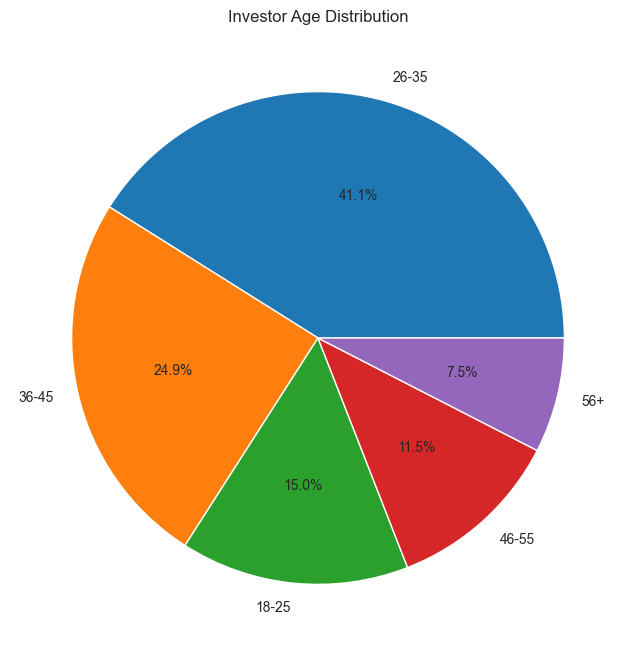

In [80]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Investor Age Distribution")
plt.ylabel("")
plt.show()

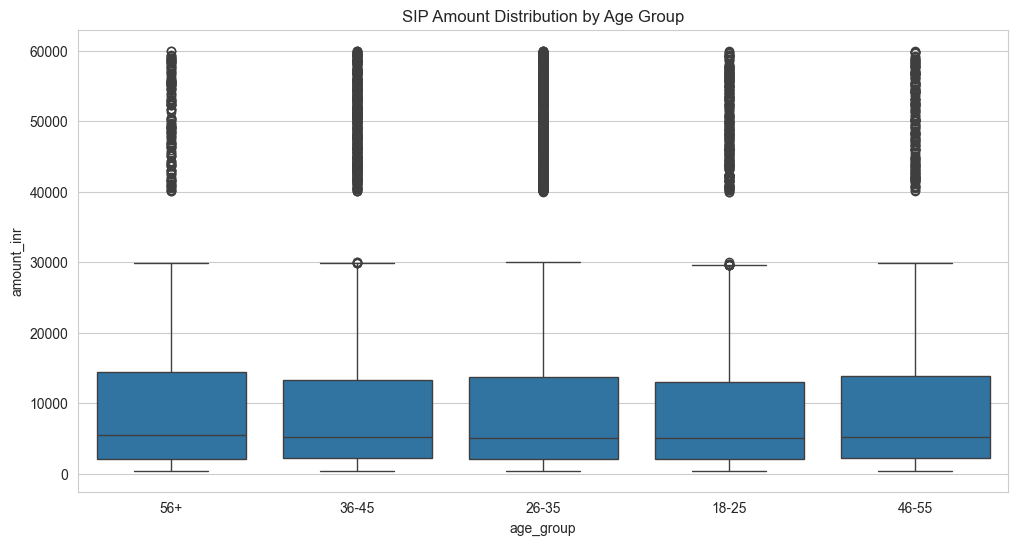

In [81]:
sip_txn = transactions[
    transactions["transaction_type"]=="SIP"
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.show()

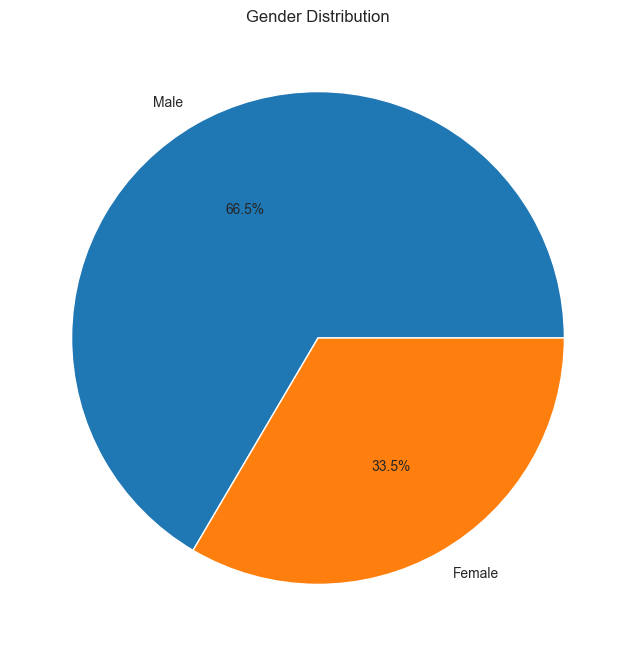

In [82]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

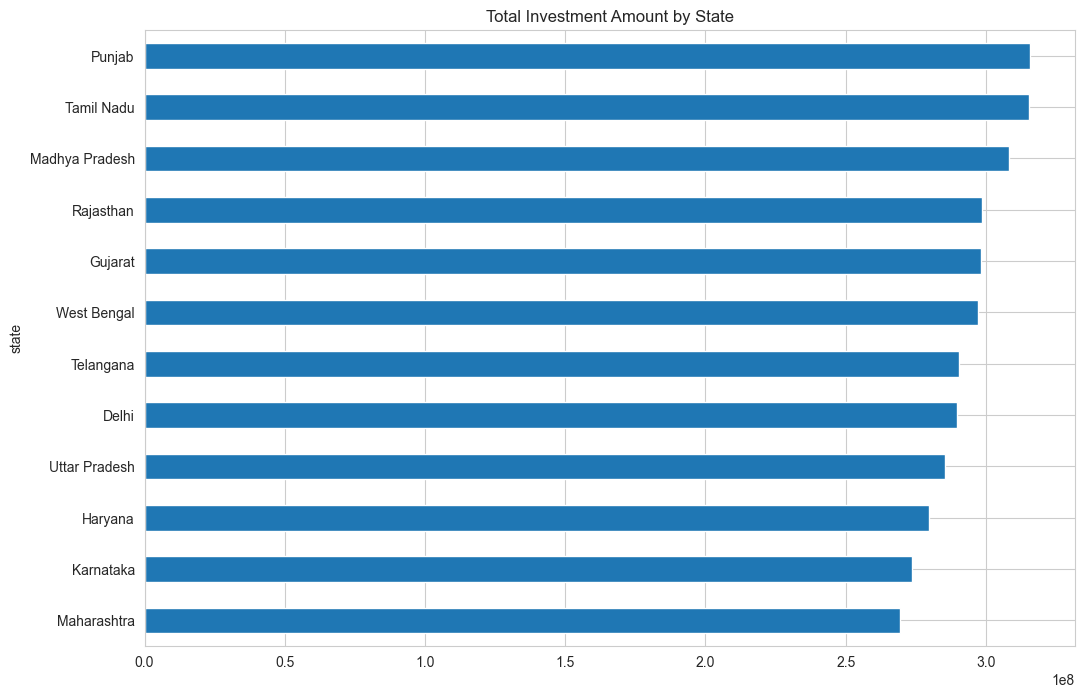

In [83]:
state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

state_data.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.show()

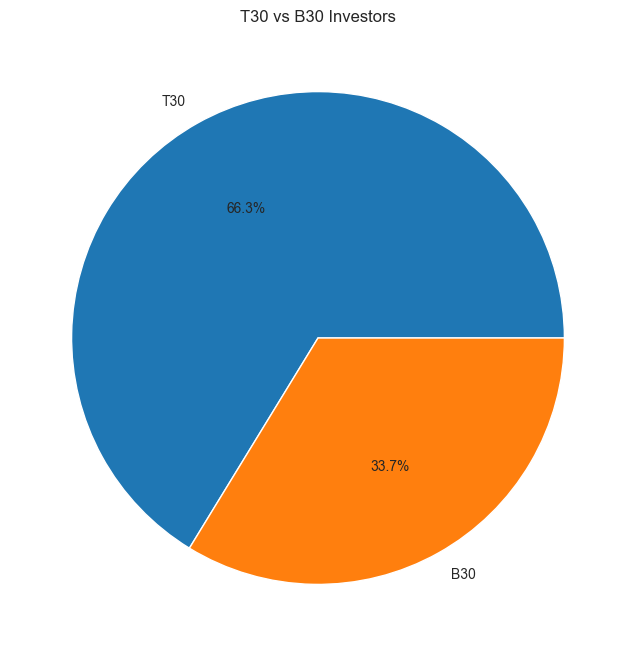

In [84]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("T30 vs B30 Investors")
plt.ylabel("")
plt.show()

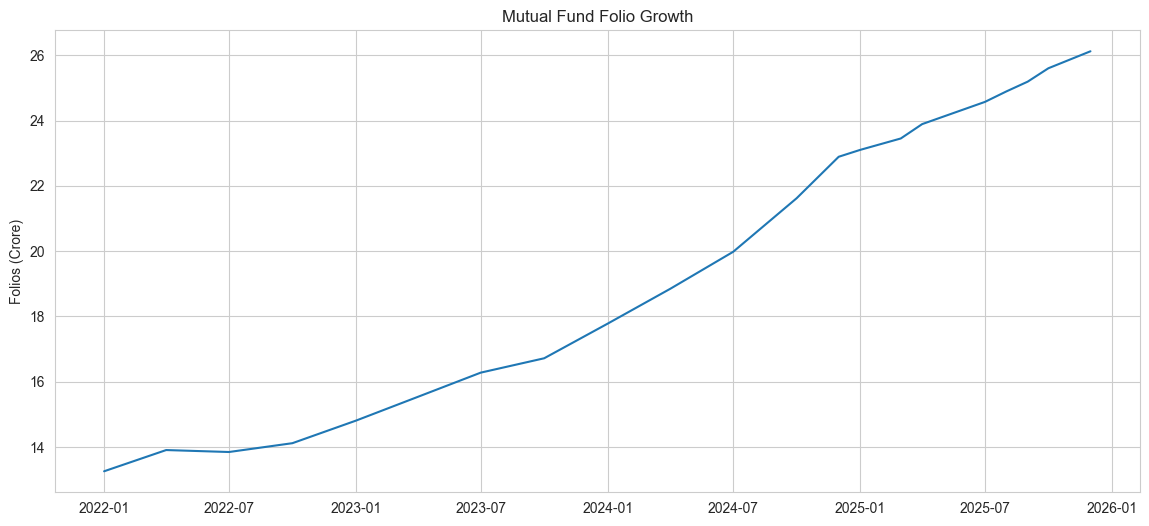

In [85]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Mutual Fund Folio Growth")
plt.ylabel("Folios (Crore)")
plt.show()

In [86]:
print(transactions["gender"].value_counts())
print(transactions["city_tier"].value_counts())
print(fund_master["scheme_name"].head(10))

gender
Male      21809
Female    10969
Name: count, dtype: int64
city_tier
T30    21719
B30    11059
Name: count, dtype: int64
0            SBI Bluechip Fund - Regular Plan - Growth
1             SBI Bluechip Fund - Direct Plan - Growth
2           SBI Small Cap Fund - Regular Plan - Growth
3            SBI Small Cap Fund - Direct Plan - Growth
4         SBI Magnum Gilt Fund - Regular Plan - Growth
5            HDFC Top 100 Fund - Regular Plan - Growth
6             HDFC Top 100 Fund - Direct Plan - Growth
7    HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8    HDFC Mid-Cap Opportunities Fund - Direct - Growth
9         HDFC Short Term Debt Fund - Regular - Growth
Name: scheme_name, dtype: object


Male investors account for 66.5% of all transactions, while female investors account for 33.5%, indicating higher participation from male investors.

T30 cities contribute 66.3% of investor transactions compared to 33.7% from B30 cities, showing stronger mutual fund penetration in major cities.

In [87]:
nav["date"] = pd.to_datetime(nav["date"])

nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = nav_pivot.pct_change()

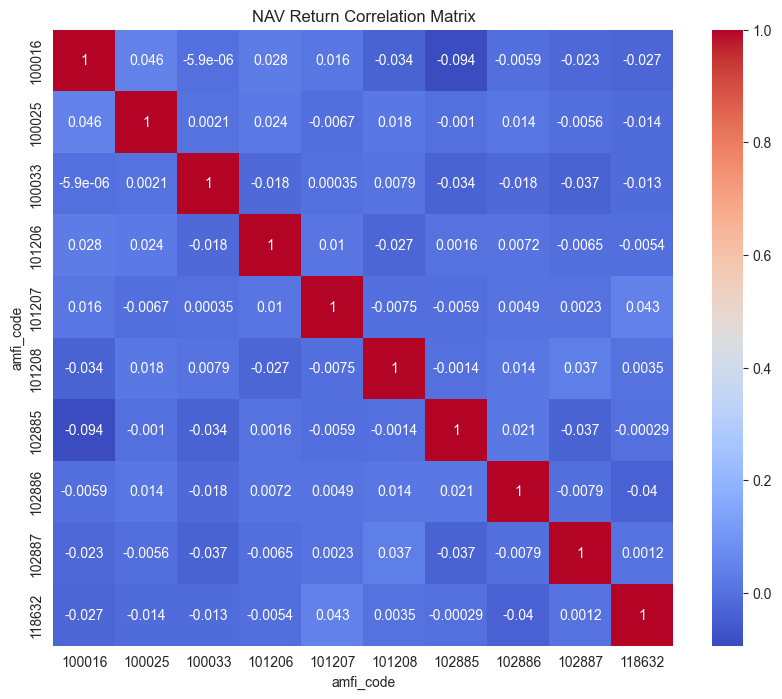

In [88]:
selected_funds = daily_returns.columns[:10]

corr_matrix = daily_returns[selected_funds].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")
plt.show()

In [89]:
sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

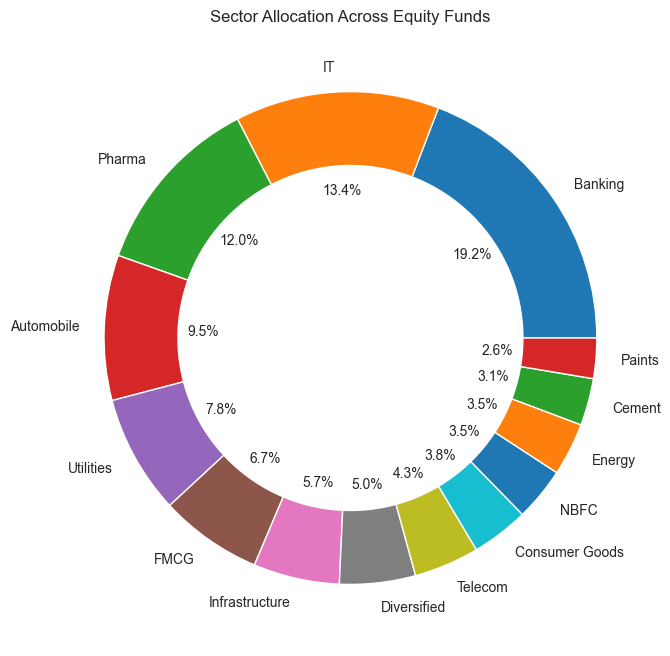

In [90]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")
plt.show()

In [91]:
plt.savefig(
    r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\reports\chart_name.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [92]:
plt.savefig(
    r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\reports\gender_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

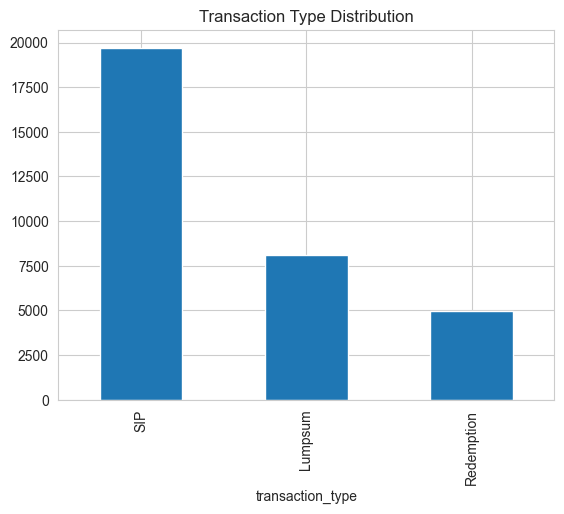

In [93]:
transactions["transaction_type"].value_counts().plot(
    kind="bar"
)

plt.title("Transaction Type Distribution")
plt.show()

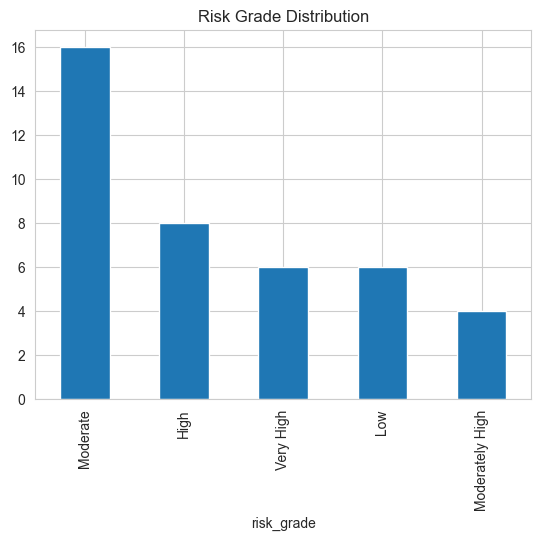

In [94]:
performance["risk_grade"].value_counts().plot(
    kind="bar"
)

plt.title("Risk Grade Distribution")
plt.show()

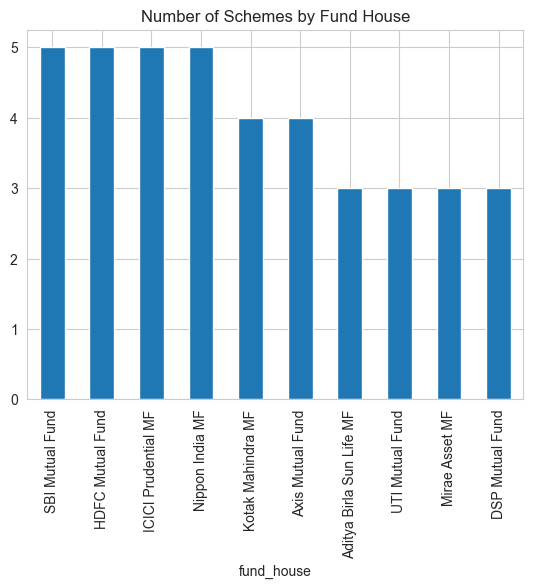

In [95]:
fund_master["fund_house"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Schemes by Fund House")
plt.show()

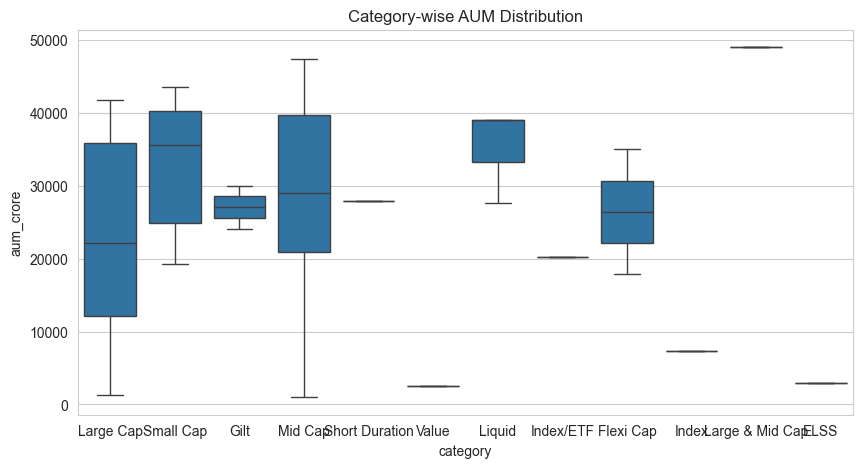

In [96]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=performance,
    x="category",
    y="aum_crore"
)

plt.title("Category-wise AUM Distribution")
plt.show()

## Key EDA Findings

1. SBI Mutual Fund maintained the highest AUM among fund houses throughout the analysis period.

2. Monthly SIP inflows showed consistent growth from 2022 to 2025.

3. December 2025 recorded the highest SIP inflow of approximately ₹31,002 crore.

4. Mutual fund folio counts increased significantly between 2022 and 2025.

5. T30 cities contributed a majority of investor transactions.

6. Male investors represented approximately two-thirds of all transactions.

7. SIP transactions were the most common transaction type.

8. Large-cap and equity-oriented schemes dominated industry assets.

9. Most schemes maintained expense ratios within industry norms.

10. Portfolio allocations were concentrated in a few key sectors such as Financials, Technology, and Banking.

In [97]:
plt.savefig(
    r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\reports\chart_name.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [98]:
plt.savefig(
    r"C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\reports\folio_growth.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

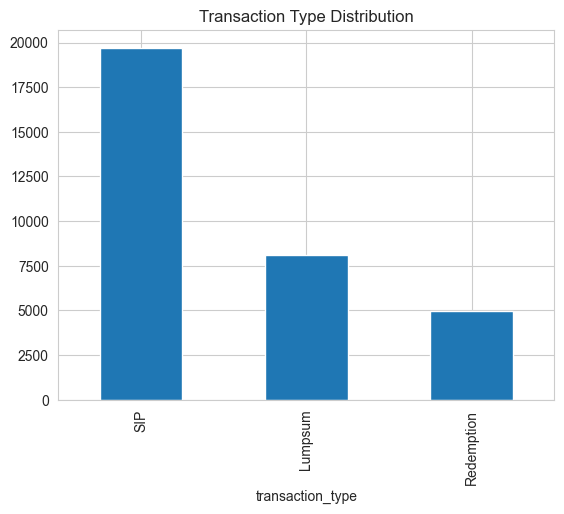

In [99]:
transactions["transaction_type"].value_counts().plot(kind="bar")
plt.title("Transaction Type Distribution")
plt.show()

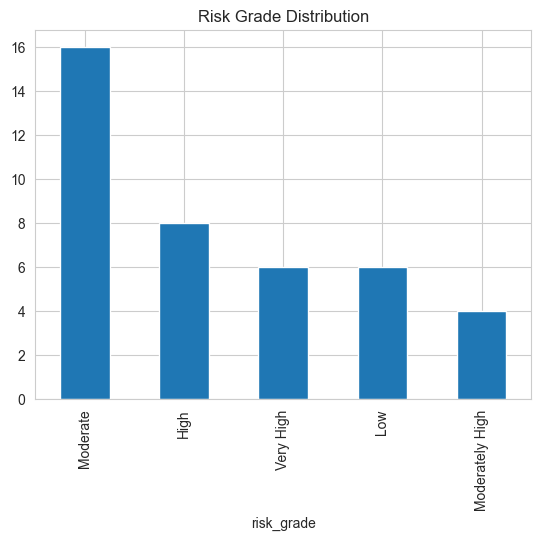

In [100]:
performance["risk_grade"].value_counts().plot(kind="bar")
plt.title("Risk Grade Distribution")
plt.show()

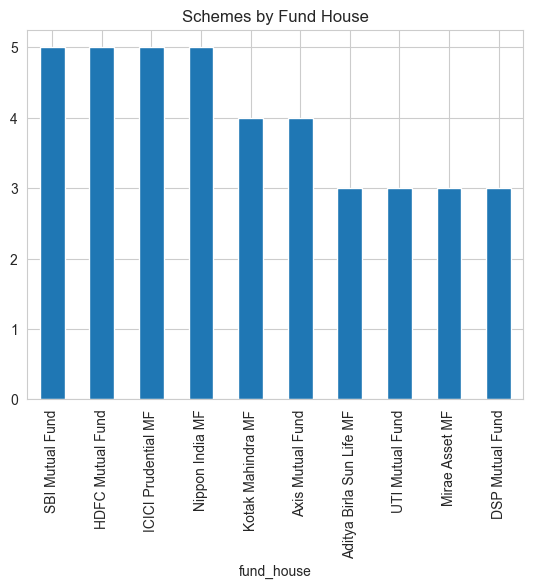

In [101]:
fund_master["fund_house"].value_counts().plot(kind="bar")
plt.title("Schemes by Fund House")
plt.show()